In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
#import numpy as np
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=250):
        """
        Args:
            csv_file (str): Path to the CSV file with protein sequences and modification labels.
            sequence_length (int): Maximum sequence length (padding shorter sequences).
        """
        # Load the CSV data
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)




    def random_shift_sequence(self,sequence, label): #does nothing for now
        """Randomly shifts a sequence and adjusts the label accordingly."""
        shift = np.random.randint(-3, 4)  # Shift left or right by up to 3 positions
        sequence = np.roll(sequence, shift, axis=0)  # Shift sequence
        label = np.roll(label, shift, axis=0)  # Shift labels accordingly
        return sequence, label

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1]
        labels = self.data.iloc[idx, 2]
    
        sequence = sequence.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = labels.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
    
        amino_acid_dict = {
            'A': [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R': [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N': [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D': [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C': [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E': [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q': [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G': [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H': [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I': [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L': [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K': [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M': [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F': [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }
    
        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]
    
        sequence_tensor = torch.tensor(sequence_indices).float()  # shape: (seq_len, features)
        labels_tensor = torch.tensor(labels).float()             # shape: (seq_len,)
    
        return sequence_tensor, labels_tensor


# Load the data into a DataLoader
dataset = ProteinDataset(csv_file="code_test_data.csv", sequence_length=33)  # Adjust sequence length based on your data
train_loader = DataLoader(dataset, batch_size=100, shuffle=True)
data_pred = ProteinDataset(csv_file="code_predict.csv", sequence_length=33)
test_loader = DataLoader(data_pred, batch_size=100, shuffle=True)
# Example: Inspecting the loaded data
for batch_idx, (sequences, labels) in enumerate(train_loader):
    print(f"Batch {batch_idx+1}:")
    print("Sequences:", sequences)
    print("Labels:", labels)


Batch 1:
Sequences: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
  

In [2]:
# cleaned_phospho_training.py

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchmetrics
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 43          # sequence window length
FEATURES = 20         # one-hot/embedding depth
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.30
CNN_FILTERS = 32
LSTM_HIDDEN = 64
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.5


# -------------------------------------------------------
# ✅ Protein Dataset
# -------------------------------------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length
        self.amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        sequence_indices = [self.amino_acid_dict[aa] for aa in sequence]
        labels = [int(l) for l in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()   # (seq_len, features)
        labels_tensor = torch.tensor(labels).float()               # (seq_len,)

        return sequence_tensor, labels_tensor


# -------------------------------------------------------
# ✅ MODEL (CNN → BiLSTM → FC)
# -------------------------------------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)

        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            fc_in = lstm_hidden * 2
        else:
            fc_in = cnn_filters
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        x = x.transpose(1, 2)                      # (batch, features, seq_len)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1, 2)                      # (batch, seq_len, channels)
        x = self.dropout(x)
        if self.use_lstm:
            x, _ = self.lstm(x)
        logits = self.fc(x).squeeze(-1)            # (batch, seq_len)
        return logits


# -------------------------------------------------------
# ✅ Focal Loss
# -------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).clamp(1e-6, 1-1e-6)
        bce = -(targets*torch.log(probs) + (1-targets)*torch.log(1-probs))
        pt = torch.where(targets==1, probs, 1-probs)
        loss = self.alpha*(1-pt)**self.gamma*bce
        return loss.mean() if self.reduction=="mean" else loss.sum()


# -------------------------------------------------------
# Instantiate model, loss, optimizer, metrics
# -------------------------------------------------------
model = PhosphoModel().to(DEVICE)
criterion = FocalLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

f1_metric = torchmetrics.classification.BinaryF1Score(threshold=THRESH)
precision_metric = torchmetrics.classification.BinaryPrecision(threshold=THRESH)
recall_metric = torchmetrics.classification.BinaryRecall(threshold=THRESH)
auroc_metric = torchmetrics.classification.BinaryAUROC()
acc_metric = torchmetrics.classification.BinaryAccuracy(threshold=THRESH)


# -------------------------------------------------------
# Training / Evaluation
# -------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    f1_metric.reset(); precision_metric.reset()
    recall_metric.reset(); auroc_metric.reset(); acc_metric.reset()
    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        logits = model(inputs)
        running_loss += criterion(logits, labels).item()
        probs = torch.sigmoid(logits).view(-1).cpu()
        labels = labels.view(-1).cpu()
        preds_bin = (probs>THRESH).int()
        f1_metric.update(preds_bin, labels)
        precision_metric.update(preds_bin, labels)
        recall_metric.update(preds_bin, labels)
        auroc_metric.update(probs, labels)
        acc_metric.update(preds_bin, labels)
    return running_loss/len(loader), {
        "val_f1": f1_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item(),
        "auroc": auroc_metric.compute().item(),
        "accuracy": acc_metric.compute().item()
    }


# -------------------------------------------------------
# REPLACE THESE WITH YOUR DATALOADERS
# -------------------------------------------------------



# -------------------------------------------------------
# Training loop with checkpoint
# -------------------------------------------------------
best_f1 = 0.0
for epoch in range(1, EPOCHS+1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, metrics = evaluate(model, val_loader, criterion)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | F1: {metrics['val_f1']:.4f}")
    if metrics["val_f1"] > best_f1:
        best_f1 = metrics["val_f1"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model (F1={best_f1:.4f}) → {CHECKPOINT_PATH}")

print("\nTraining complete.")
print(f"Best model F1: {best_f1:.4f}")


NameError: name 'val_loader' is not defined

In [4]:
# phospho_training_full.py

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchmetrics
import pandas as pd

# --------------------------
# DEVICE & HYPERPARAMETERS
# --------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33          # sequence window length
FEATURES = 20         # one-hot depth for amino acids
BATCH_SIZE = 100
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.30
CNN_FILTERS = 32
LSTM_HIDDEN = 64
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.5

# --------------------------
# DATASET
# --------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1]
        labels = self.data.iloc[idx, 2]

        # Clean strings
        sequence = sequence.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = labels.replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')

        # One-hot encoding dictionary
        amino_acid_dict = {
            'A': [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R': [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N': [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D': [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C': [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E': [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q': [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G': [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H': [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I': [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L': [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K': [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M': [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F': [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()  # (seq_len, features)
        labels_tensor = torch.tensor(labels).float()             # (seq_len,)

        return sequence_tensor, labels_tensor

# --------------------------
# SPLIT DATASET
# --------------------------
full_dataset = ProteinDataset(csv_file="code_test_data.csv", sequence_length=SEQ_LEN)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --------------------------
# MODEL
# --------------------------
class PhosphoModel(nn.Module):
    def __init__(self,
                 seq_len=SEQ_LEN,
                 input_dim=FEATURES,
                 cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN,
                 use_lstm=USE_LSTM,
                 dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm

        self.conv1 = nn.Conv1d(input_dim, cnn_filters, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)

        if use_lstm:
            self.lstm = nn.LSTM(
                input_size=cnn_filters,
                hidden_size=lstm_hidden,
                bidirectional=True,
                batch_first=True
            )
            fc_in = lstm_hidden * 2
        else:
            fc_in = cnn_filters

        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        # x: [batch, seq_len, features] → [batch, features, seq_len] for Conv1d
        x = x.transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = x.transpose(1, 2)  # back to [batch, seq_len, channels]
        x = self.dropout(x)

        if self.use_lstm:
            x, _ = self.lstm(x)

        logits = self.fc(x).squeeze(-1)  # [batch, seq_len]
        return logits

# --------------------------
# LOSS, OPTIMIZER, METRICS
# --------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).clamp(1e-6, 1-1e-6)
        bce = -(targets * torch.log(probs) + (1 - targets) * torch.log(1 - probs))
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean() if self.reduction == "mean" else loss.sum()

model = PhosphoModel().to(DEVICE)
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=LR)

# Torchmetrics
f1_metric = torchmetrics.classification.BinaryF1Score(threshold=THRESH)
precision_metric = torchmetrics.classification.BinaryPrecision(threshold=THRESH)
recall_metric = torchmetrics.classification.BinaryRecall(threshold=THRESH)
auroc_metric = torchmetrics.classification.BinaryAUROC()
acc_metric = torchmetrics.classification.BinaryAccuracy(threshold=THRESH)

# --------------------------
# TRAIN/EVAL FUNCTIONS
# --------------------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    f1_metric.reset(); precision_metric.reset()
    recall_metric.reset(); auroc_metric.reset(); acc_metric.reset()

    for inputs, labels in loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        logits = model(inputs)
        running_loss += criterion(logits, labels).item()

        probs = torch.sigmoid(logits).view(-1).cpu()
        labels = labels.view(-1).cpu()
        preds_bin = (probs > THRESH).int()

        f1_metric.update(preds_bin, labels)
        precision_metric.update(preds_bin, labels)
        recall_metric.update(preds_bin, labels)
        auroc_metric.update(probs, labels)
        acc_metric.update(preds_bin, labels)

    return running_loss / len(loader), {
        "val_f1": f1_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item(),
        "auroc": auroc_metric.compute().item(),
        "accuracy": acc_metric.compute().item()
    }

# --------------------------
# TRAINING LOOP
# --------------------------
best_f1 = 0.0
for epoch in range(1, EPOCHS+1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, metrics = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | F1: {metrics['val_f1']:.4f}")

    if metrics["val_f1"] > best_f1:
        best_f1 = metrics["val_f1"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model (F1={best_f1:.4f}) → {CHECKPOINT_PATH}")

print("\nTraining complete.")
print(f"Best model F1: {best_f1:.4f}")


Epoch 1/200 | Train Loss: 0.0260 | Val Loss: 0.0192 | F1: 0.0003
✅ Saved best model (F1=0.0003) → best_phospho_model.pth
Epoch 2/200 | Train Loss: 0.0156 | Val Loss: 0.0119 | F1: 0.5891
✅ Saved best model (F1=0.5891) → best_phospho_model.pth
Epoch 3/200 | Train Loss: 0.0111 | Val Loss: 0.0101 | F1: 0.6993
✅ Saved best model (F1=0.6993) → best_phospho_model.pth
Epoch 4/200 | Train Loss: 0.0102 | Val Loss: 0.0098 | F1: 0.7080
✅ Saved best model (F1=0.7080) → best_phospho_model.pth
Epoch 5/200 | Train Loss: 0.0099 | Val Loss: 0.0095 | F1: 0.7176
✅ Saved best model (F1=0.7176) → best_phospho_model.pth
Epoch 6/200 | Train Loss: 0.0096 | Val Loss: 0.0094 | F1: 0.7295
✅ Saved best model (F1=0.7295) → best_phospho_model.pth
Epoch 7/200 | Train Loss: 0.0094 | Val Loss: 0.0092 | F1: 0.7385
✅ Saved best model (F1=0.7385) → best_phospho_model.pth
Epoch 8/200 | Train Loss: 0.0092 | Val Loss: 0.0091 | F1: 0.7444
✅ Saved best model (F1=0.7444) → best_phospho_model.pth
Epoch 9/200 | Train Loss: 0.0090

# same model above but with everything printed


Epoch 1/200 | Train Loss: 0.0133 | Val Loss: 0.0091 | F1: 0.9349 | Precision: 1.0000 | Recall: 0.8780 | PosAcc: 0.8780
✅ Saved best model with F1: 0.9349
Epoch 2/200 | Train Loss: 0.0097 | Val Loss: 0.0083 | F1: 0.9500 | Precision: 1.0000 | Recall: 0.9050 | PosAcc: 0.9050
✅ Saved best model with F1: 0.9500
Epoch 3/200 | Train Loss: 0.0084 | Val Loss: 0.0076 | F1: 0.9448 | Precision: 1.0000 | Recall: 0.8957 | PosAcc: 0.8957
Epoch 4/200 | Train Loss: 0.0078 | Val Loss: 0.0073 | F1: 0.9406 | Precision: 1.0000 | Recall: 0.8881 | PosAcc: 0.8881
Epoch 5/200 | Train Loss: 0.0076 | Val Loss: 0.0071 | F1: 0.9397 | Precision: 1.0000 | Recall: 0.8866 | PosAcc: 0.8866
Epoch 6/200 | Train Loss: 0.0075 | Val Loss: 0.0070 | F1: 0.9411 | Precision: 1.0000 | Recall: 0.8892 | PosAcc: 0.8892
Epoch 7/200 | Train Loss: 0.0073 | Val Loss: 0.0071 | F1: 0.9492 | Precision: 1.0000 | Recall: 0.9036 | PosAcc: 0.9036
Epoch 8/200 | Train Loss: 0.0072 | Val Loss: 0.0067 | F1: 0.9405 | Precision: 1.0000 | Recall: 0.

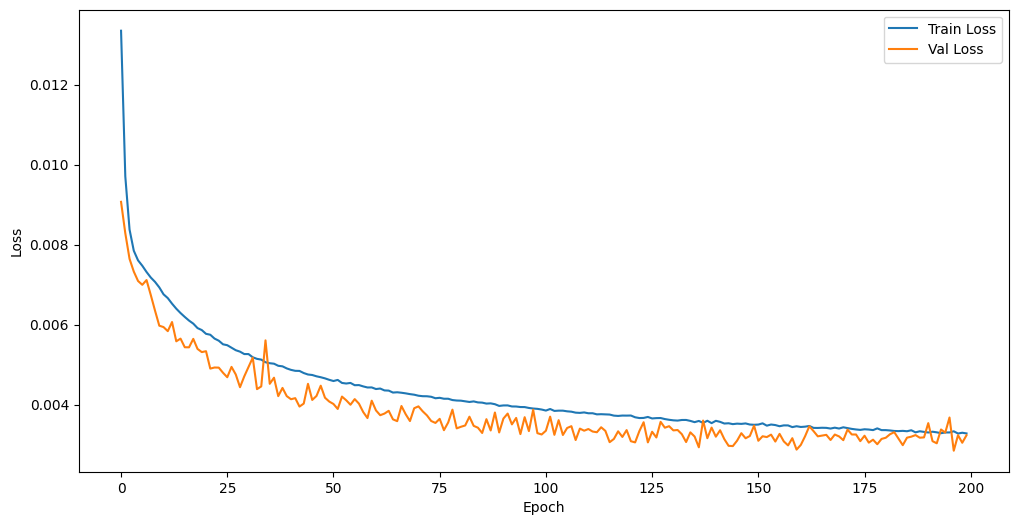

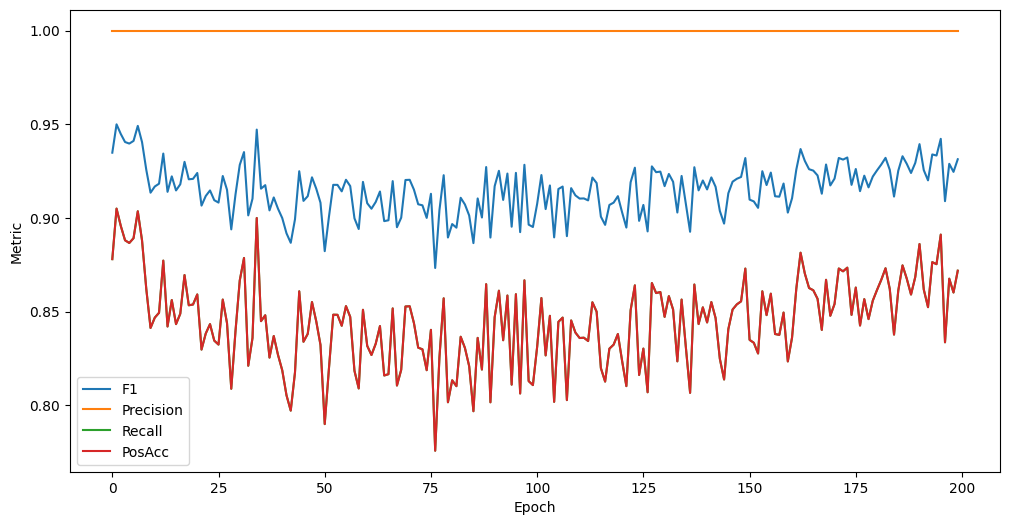

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# ----------------------------
# Config
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33
FEATURES = 20
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.3
CNN_FILTERS = 32
LSTM_HIDDEN = 64
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.5

# ----------------------------
# Dataset
# ----------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')

        amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()
        labels_tensor = torch.tensor(labels).float()
        return sequence_tensor, labels_tensor

# ----------------------------
# Model
# ----------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)
        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            fc_in = lstm_hidden*2
        else:
            fc_in = cnn_filters
        self.fc = nn.Linear(fc_in,1)

    def forward(self,x):
        x = x.transpose(1,2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1,2)
        x = self.dropout(x)
        if self.use_lstm:
            x,_ = self.lstm(x)
        logits = self.fc(x).squeeze(-1)
        return logits

# ----------------------------
# Positive-only Focal Loss
# ----------------------------
class PosFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).clamp(1e-6, 1-1e-6)
        bce = -(targets*torch.log(probs) + (1-targets)*torch.log(1-probs))
        pt = torch.where(targets==1, probs, 1-probs)
        loss = self.alpha*(1-pt)**self.gamma * bce

        # Only consider positions where target==1 or prediction > 0.5
        mask = (targets==1) | (probs>0.5)
        loss = loss * mask.float()

        return loss.mean() if self.reduction=="mean" else loss.sum()

# ----------------------------
# Positive-only metrics
# ----------------------------
def positive_only_metrics(logits, targets, threshold=0.5):
    logits = logits.view(-1).detach().cpu()
    targets = targets.view(-1).detach().cpu()

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).int()

    pos_mask = targets == 1

    if pos_mask.sum() == 0:
        return {"f1":0.0, "precision":0.0, "recall":0.0, "pos_acc":0.0}

    pos_preds = preds[pos_mask]
    pos_targets = targets[pos_mask]

    f1 = f1_score(pos_targets, pos_preds, zero_division=0)
    precision = precision_score(pos_targets, pos_preds, zero_division=0)
    recall = recall_score(pos_targets, pos_preds, zero_division=0)
    pos_acc = (pos_preds == pos_targets).sum().float() / pos_mask.sum()

    return {"f1": f1, "precision": precision, "recall": recall, "pos_acc": pos_acc}

# ----------------------------
# Instantiate model, optimizer, criterion
# ----------------------------
model = PhosphoModel().to(DEVICE)
criterion = PosFocalLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# Loaders
# ----------------------------
dataset = ProteinDataset("code_test_data.csv")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Training & Validation Loop
# ----------------------------
# ----------------------------
# Training & Validation Loop
# ----------------------------
best_f1 = 0
history = {"train_loss":[],"val_loss":[],"val_f1":[],"precision":[],"recall":[],"pos_acc":[]}

for epoch in range(1, EPOCHS+1):
    # ---- Training ----
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    history["train_loss"].append(train_loss)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    metrics_sum = {"f1":0,"precision":0,"recall":0,"pos_acc":0}
    count = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
            logits = model(inputs)
            val_loss += criterion(logits, labels).item()
            batch_metrics = positive_only_metrics(logits, labels, threshold=THRESH)
            for k in metrics_sum:
                metrics_sum[k] += batch_metrics[k]
            count += 1

    val_loss /= len(val_loader)
    val_metrics = {k: metrics_sum[k]/count for k in metrics_sum}

    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_metrics["f1"])
    history["precision"].append(val_metrics["precision"])
    history["recall"].append(val_metrics["recall"])
    history["pos_acc"].append(val_metrics["pos_acc"])

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} "
          f"| F1: {val_metrics['f1']:.4f} | Precision: {val_metrics['precision']:.4f} | "
          f"Recall: {val_metrics['recall']:.4f} | PosAcc: {val_metrics['pos_acc']:.4f}")

    # Save best model
    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model with F1: {best_f1:.4f}")

    # ---- Show predictions every 10 epochs ----
    if epoch % 10 == 0:
        val_batch = next(iter(val_loader))
        inputs, labels = val_batch
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        logits = model(inputs)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESH).int()

        preds = preds.detach().cpu().numpy()
        labels = labels.detach().cpu().numpy()

        print(f"\n--- Sample Predictions at Epoch {epoch} ---")
        for i in range(min(3, len(preds))):  # show first 3 sequences
            print(f"True: {labels[i]}")
            print(f"Pred: {preds[i]}")
            print("-"*40)

# ----------------------------
# Plot metrics
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history["val_f1"], label="F1")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.plot(history["pos_acc"], label="PosAcc")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.show()


In [3]:
# Recommended way in Jupyter Notebook
#%pip install pandas torch torchmetrics matplotlib
#%pip install scikit-learn


   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ----------------------- ---------------- 5.2/8.9 MB 29.0 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 30.6 MB/s  0:00:00
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ------- -------------------------------- 7.6/41.3 MB 36.2 MB/s eta 0:00:01
   --------------- ------------------------ 16.3/41.3 MB 39.4 MB/s eta 0:00:01
   ------------------------ --------------- 25.4/41.3 MB 41.3 MB/s eta 0:00:01
   --------------------------------- ------ 34.3/41.3 MB 42.0 MB/s eta 0:00:01
   ---------------------------------------  40.9/41.3 MB 40.0 MB/s eta 0:00:01
   ---------------------------------------- 41.3/41.3 MB 37.0 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -

# two csv sets (broken)

Epoch 1/200 | Train Loss: 0.7295 | Test Loss: 0.5708 | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000 | PosAcc: 0.0000
Epoch 2/200 | Train Loss: 0.5120 | Test Loss: 0.3782 | F1: 0.2388 | Precision: 1.0000 | Recall: 0.1402 | PosAcc: 0.1402
✅ Saved best model with F1: 0.2388
Epoch 3/200 | Train Loss: 0.3694 | Test Loss: 0.2665 | F1: 0.8383 | Precision: 1.0000 | Recall: 0.7279 | PosAcc: 0.7279
✅ Saved best model with F1: 0.8383
Epoch 4/200 | Train Loss: 0.3145 | Test Loss: 0.2491 | F1: 0.8979 | Precision: 1.0000 | Recall: 0.8187 | PosAcc: 0.8187
✅ Saved best model with F1: 0.8979
Epoch 5/200 | Train Loss: 0.2910 | Test Loss: 0.2448 | F1: 0.9053 | Precision: 1.0000 | Recall: 0.8308 | PosAcc: 0.8308
✅ Saved best model with F1: 0.9053
Epoch 6/200 | Train Loss: 0.2786 | Test Loss: 0.2421 | F1: 0.8976 | Precision: 1.0000 | Recall: 0.8186 | PosAcc: 0.8186
Epoch 7/200 | Train Loss: 0.2703 | Test Loss: 0.2409 | F1: 0.8920 | Precision: 1.0000 | Recall: 0.8095 | PosAcc: 0.8095
Epoch 8/200 | Train 

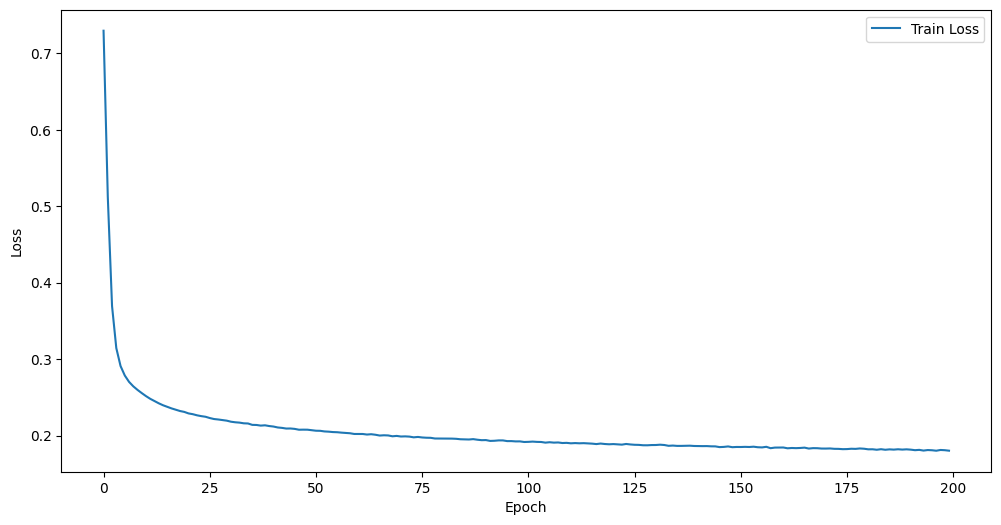

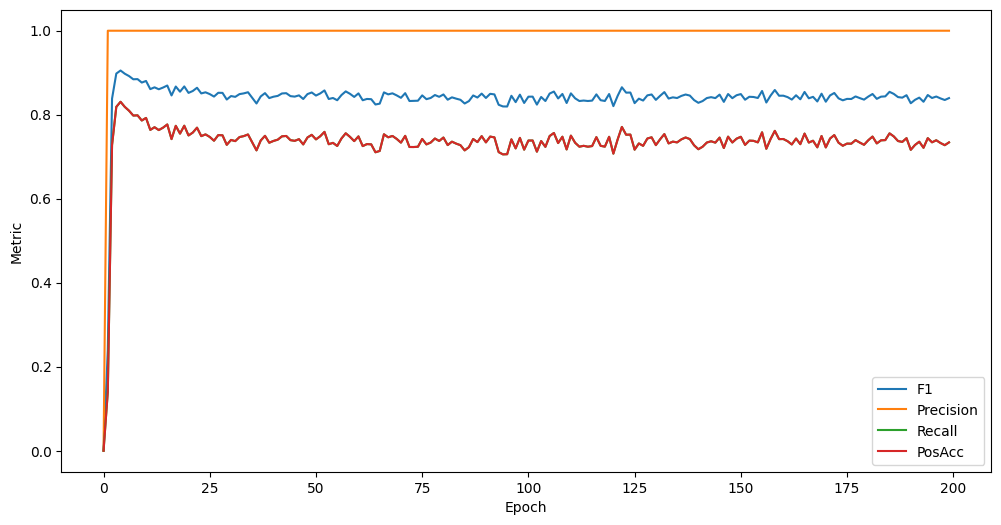

In [10]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# ----------------------------
# Config
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33
FEATURES = 20
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.50
CNN_FILTERS = 16
LSTM_HIDDEN = 32
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.55

# ----------------------------
# Dataset
# ----------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','').replace("'",'').replace(" ",'').replace('[','').replace(']','')

        amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()
        labels_tensor = torch.tensor(labels).float()
        return sequence_tensor, labels_tensor

# ----------------------------
# Model
# ----------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)
        
        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            self.lstm_dropout = nn.Dropout(dropout)  # <-- dropout after LSTM
            fc_in = lstm_hidden*2
        else:
            fc_in = cnn_filters
        
        self.fc = nn.Linear(fc_in,1)

    def forward(self,x):
        # CNN
        x = x.transpose(1,2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1,2)
        x = self.dropout(x)
        
        # LSTM
        if self.use_lstm:
            x,_ = self.lstm(x)
            x = self.lstm_dropout(x)  # <-- apply dropout here
        
        logits = self.fc(x).squeeze(-1)
        return logits


# ----------------------------
# Positive-only Focal Loss
# ----------------------------
class SparsePosFocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=1.0, pos_weight=5.0, neg_weight=3, reduction="mean"):
        """
        alpha: base focal loss alpha
        gamma: focal focusing parameter
        pos_weight: weight for missed positives (FN)
        neg_weight: weight for false positives (FP)
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight
        self.reduction = reduction

    def forward(self, logits, targets):
        # probs
        probs = torch.sigmoid(logits).clamp(1e-6, 1-1e-6)
        # BCE
        bce = -(targets * torch.log(probs) + (1 - targets) * torch.log(1 - probs))
        # focal term
        pt = torch.where(targets==1, probs, 1-probs)
        focal = (1 - pt)**self.gamma

        # weight positives and negatives separately
        weights = torch.where(targets==1, self.pos_weight, self.neg_weight)
        loss = self.alpha * focal * bce * weights

        if self.reduction=="mean":
            return loss.mean()
        else:
            return loss.sum()



# ----------------------------
# Positive-only metrics
# ----------------------------
def positive_only_metrics(logits, targets, threshold=0.5):
    logits = logits.view(-1).detach().cpu()
    targets = targets.view(-1).detach().cpu()

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).int()

    pos_mask = targets == 1

    if pos_mask.sum() == 0:
        return {"f1":0.0, "precision":0.0, "recall":0.0, "pos_acc":0.0}

    pos_preds = preds[pos_mask]
    pos_targets = targets[pos_mask]

    f1 = f1_score(pos_targets, pos_preds, zero_division=0)
    precision = precision_score(pos_targets, pos_preds, zero_division=0)
    recall = recall_score(pos_targets, pos_preds, zero_division=0)
    pos_acc = (pos_preds == pos_targets).sum().float() / pos_mask.sum()

    return {"f1": f1, "precision": precision, "recall": recall, "pos_acc": pos_acc}

# ----------------------------
# Instantiate model, optimizer, criterion
# ----------------------------
model = PhosphoModel().to(DEVICE)
criterion = SparsePosFocalLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# Load training dataset (all 18k)
# ----------------------------
train_dataset = ProteinDataset("code_test_data.csv")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ----------------------------
# Load testing dataset
# ----------------------------
test_dataset = ProteinDataset("code_predict.csv")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Training Loop
# ----------------------------
best_f1 = 0
history = {"train_loss":[],"test_f1":[],"precision":[],"recall":[],"pos_acc":[]}

for epoch in range(1, EPOCHS+1):
    # ---- Training ----
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    history["train_loss"].append(train_loss)

    # ---- Testing ----
    model.eval()
    test_loss = 0
    metrics_sum = {"f1":0,"precision":0,"recall":0,"pos_acc":0}
    count = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
            logits = model(inputs)
            test_loss += criterion(logits, labels).item()
            batch_metrics = positive_only_metrics(logits, labels, threshold=THRESH)
            for k in metrics_sum:
                metrics_sum[k] += batch_metrics[k]
            count += 1

    test_loss /= len(test_loader)
    test_metrics = {k: metrics_sum[k]/count for k in metrics_sum}

    history["test_f1"].append(test_metrics["f1"])
    history["precision"].append(test_metrics["precision"])
    history["recall"].append(test_metrics["recall"])
    history["pos_acc"].append(test_metrics["pos_acc"])

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} "
          f"| F1: {test_metrics['f1']:.4f} | Precision: {test_metrics['precision']:.4f} | "
          f"Recall: {test_metrics['recall']:.4f} | PosAcc: {test_metrics['pos_acc']:.4f}")

    # Save best model
    if test_metrics["f1"] > best_f1:
        best_f1 = test_metrics["f1"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model with F1: {best_f1:.4f}")

    # ---- Show predictions every 10 epochs ----
    if epoch % 10 == 0:
        test_batch = next(iter(test_loader))
        inputs, labels = test_batch
        inputs, labels = inputs.float().to(DEVICE), labels.float().to(DEVICE)
        logits = model(inputs)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESH).int()

        preds = preds.detach().cpu().numpy()
        labels = labels.detach().cpu().numpy()

        print(f"\n--- Sample Predictions at Epoch {epoch} ---")
        for i in range(min(3, len(preds))):
            print(f"True: {labels[i]}")
            print(f"Pred: {preds[i]}")
            print("-"*40)

# ----------------------------
# Plot metrics
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history["test_f1"], label="F1")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.plot(history["pos_acc"], label="PosAcc")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.show()


Epoch 1/200 | Train Loss: 1.570177 | Test Loss: 1.215869 | F1: 0.6045 | Precision: 0.5463 | Recall: 0.6766 | TP: 12429 FP: 10321 FN: 5941
✅ Saved best model with F1: 0.6045
Epoch 2/200 | Train Loss: 0.964388 | Test Loss: 0.664066 | F1: 0.7103 | Precision: 0.5612 | Recall: 0.9676 | TP: 17774 FP: 13900 FN: 596
✅ Saved best model with F1: 0.7103
Epoch 3/200 | Train Loss: 0.737340 | Test Loss: 0.606398 | F1: 0.7139 | Precision: 0.5595 | Recall: 0.9857 | TP: 18108 FP: 14254 FN: 262
✅ Saved best model with F1: 0.7139
Epoch 4/200 | Train Loss: 0.669933 | Test Loss: 0.592554 | F1: 0.7138 | Precision: 0.5596 | Recall: 0.9852 | TP: 18098 FP: 14243 FN: 272
Epoch 5/200 | Train Loss: 0.639410 | Test Loss: 0.586457 | F1: 0.7151 | Precision: 0.5609 | Recall: 0.9862 | TP: 18116 FP: 14181 FN: 254
✅ Saved best model with F1: 0.7151
Epoch 6/200 | Train Loss: 0.618986 | Test Loss: 0.581998 | F1: 0.7168 | Precision: 0.5639 | Recall: 0.9834 | TP: 18065 FP: 13972 FN: 305
✅ Saved best model with F1: 0.7168
Ep

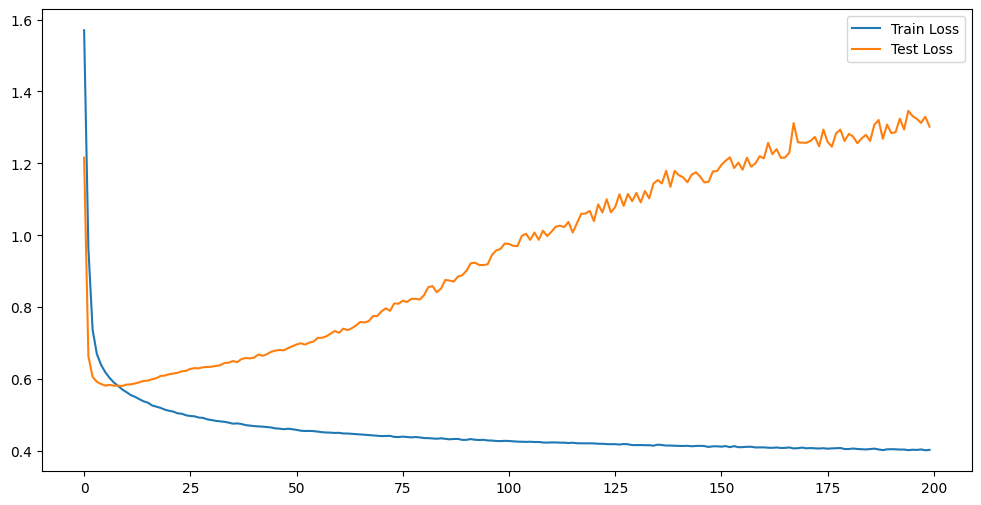

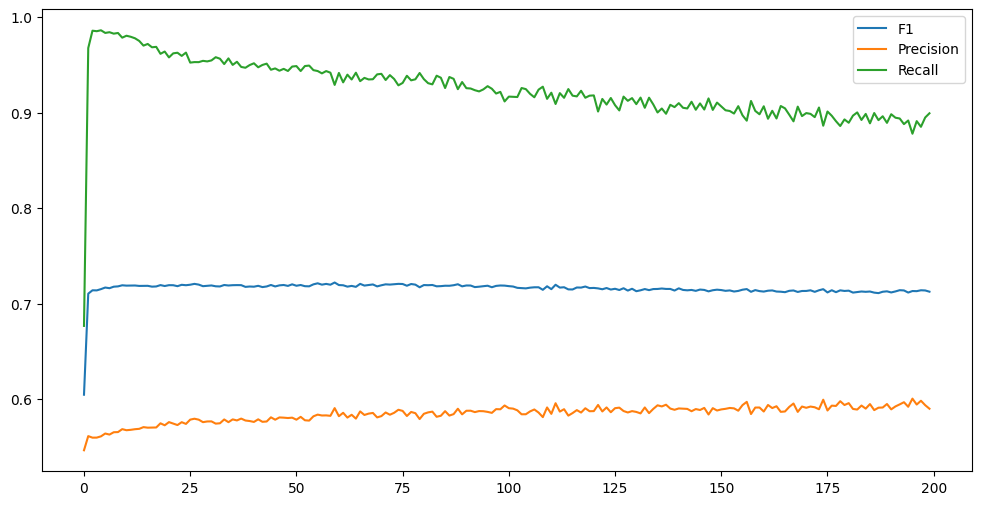

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# ----------------------------
# Config
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33
FEATURES = 20
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.50
CNN_FILTERS = 16
LSTM_HIDDEN = 32
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.55  # threshold used for converting probs -> preds

# ----------------------------
# Dataset (unchanged)
# ----------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','')\
                                         .replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','')\
                                      .replace("'",'').replace(" ",'').replace('[','').replace(']','')

        amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()
        labels_tensor = torch.tensor(labels).float()
        return sequence_tensor, labels_tensor

# ----------------------------
# Model (unchanged)
# ----------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)
        
        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            self.lstm_dropout = nn.Dropout(dropout)
            fc_in = lstm_hidden*2
        else:
            fc_in = cnn_filters
        
        self.fc = nn.Linear(fc_in,1)

    def forward(self,x):
        x = x.transpose(1,2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1,2)
        x = self.dropout(x)
        
        if self.use_lstm:
            x,_ = self.lstm(x)
            x = self.lstm_dropout(x)
        
        logits = self.fc(x).squeeze(-1)
        return logits

# ---------------------------------------------------------------
# NEW PTM CORRECTED FOCAL LOSS (fixes your extremely low loss)
# ---------------------------------------------------------------
class PTMFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=20.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        # standard BCE with class weighting
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=torch.tensor([self.pos_weight], device=logits.device),
            reduction="none"
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = (1 - pt) ** self.gamma

        alpha_factor = torch.where(targets == 1, self.alpha, 1 - self.alpha)

        loss = focal * alpha_factor * bce

        # normalize by positive count, like in PTM research
        num_pos = targets.sum() + 1e-6
        return loss.sum() / num_pos

# ----------------------------
# Instantiate model + optimizer + NEW loss
# ----------------------------
model = PhosphoModel().to(DEVICE)
criterion = PTMFocalLoss(alpha=0.25, gamma=2.0, pos_weight=20.0)
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# Load datasets (unchanged)
# ----------------------------
train_dataset = ProteinDataset("code_test_data.csv")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ProteinDataset("code_predict.csv")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Training Loop (unchanged except using new loss)
# ----------------------------
best_f1 = 0.0
history = {"train_loss":[],"test_loss":[],"test_f1":[],"precision":[],"recall":[],"pos_acc":[]}

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    train_steps = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_steps += 1

    train_loss /= train_steps
    history["train_loss"].append(train_loss)

    model.eval()
    test_loss = 0.0
    test_steps = 0
    total_tp = total_fp = total_fn = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            loss = criterion(logits, labels).item()
            test_loss += loss
            test_steps += 1

            tp, fp, fn = (
                ((torch.sigmoid(logits) > THRESH).int() == 1) &
                (labels.int() == 1)
            ).sum().item(), \
            (((torch.sigmoid(logits) > THRESH).int() == 1) &
             (labels.int() == 0)).sum().item(), \
            (((torch.sigmoid(logits) > THRESH).int() == 0) &
             (labels.int() == 1)).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn

    test_loss /= test_steps
    history["test_loss"].append(test_loss)

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    history["test_f1"].append(f1)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["pos_acc"].append(recall)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} "
          f"| F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | TP: {total_tp} FP: {total_fp} FN: {total_fn}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model with F1: {best_f1:.4f}")

    # ---- Show predictions every 10 epochs ----
    if epoch % 10 == 0:
        test_batch = next(iter(test_loader))
        inputs_b, labels_b = test_batch
        inputs_b, labels_b = inputs_b.to(DEVICE), labels_b.to(DEVICE)
        logits_b = model(inputs_b)
        preds_b = (torch.sigmoid(logits_b) > THRESH).int()

        print(f"\n--- Predictions at Epoch {epoch} ---")
        for i in range(3):
            print("True:", labels_b[i].cpu().numpy())
            print("Pred:", preds_b[i].cpu().numpy())
            print("-"*40)

# ----------------------------
# Plot metrics
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history["test_f1"], label="F1")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.legend()
plt.show()


# with confusion matrix

In [22]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# ----------------------------
# Config
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33
FEATURES = 20
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.70
CNN_FILTERS = 64
LSTM_HIDDEN = 8
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.50  # threshold used for converting probs -> preds

# ----------------------------
# Dataset
# ----------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','')\
                                         .replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','')\
                                      .replace("'",'').replace(" ",'').replace('[','').replace(']','')

        amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()
        labels_tensor = torch.tensor(labels).float()
        return sequence_tensor, labels_tensor

# ----------------------------
# Model
# ----------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)
        
        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            self.lstm_dropout = nn.Dropout(dropout)
            fc_in = lstm_hidden*2
        else:
            fc_in = cnn_filters
        
        self.fc = nn.Linear(fc_in,1)

    def forward(self,x):
        x = x.transpose(1,2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1,2)
        x = self.dropout(x)
        
        if self.use_lstm:
            x,_ = self.lstm(x)
            x = self.lstm_dropout(x)
        
        logits = self.fc(x).squeeze(-1)
        return logits

# ----------------------------
# PTM Focal Loss
# ----------------------------
class PTMFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=20.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=torch.tensor([self.pos_weight], device=logits.device),
            reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = (1 - pt) ** self.gamma
        alpha_factor = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        loss = focal * alpha_factor * bce
        num_pos = targets.sum() + 1e-6
        return loss.sum() / num_pos

# ----------------------------
# Instantiate model
# ----------------------------
model = PhosphoModel().to(DEVICE)
criterion = PTMFocalLoss(alpha=0.7, gamma=2.0, pos_weight=20.0)
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# Load datasets
# ----------------------------
train_dataset = ProteinDataset("code_test_data.csv")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ProteinDataset("code_predict.csv")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Training loop
# ----------------------------
best_f1 = 0.0
history = {"train_loss":[],"test_loss":[],"test_f1":[],"precision":[],"recall":[],"pos_acc":[]}

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    train_steps = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_steps += 1

    train_loss /= train_steps
    history["train_loss"].append(train_loss)

    # ---- Evaluation ----
    model.eval()
    test_loss = 0.0
    test_steps = 0
    total_tp = total_fp = total_fn = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            loss = criterion(logits, labels).item()
            test_loss += loss
            test_steps += 1

            tp, fp, fn = (
                ((torch.sigmoid(logits) > THRESH).int() == 1) &
                (labels.int() == 1)
            ).sum().item(), \
            (((torch.sigmoid(logits) > THRESH).int() == 1) &
             (labels.int() == 0)).sum().item(), \
            (((torch.sigmoid(logits) > THRESH).int() == 0) &
             (labels.int() == 1)).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn

    test_loss /= test_steps
    history["test_loss"].append(test_loss)

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    history["test_f1"].append(f1)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["pos_acc"].append(recall)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} "
          f"| F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | TP: {total_tp} FP: {total_fp} FN: {total_fn}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model with F1: {best_f1:.4f}")

    # ---- Show predictions every 10 epochs ----
    if epoch % 10 == 0:
        test_batch = next(iter(test_loader))
        inputs_b, labels_b = test_batch
        inputs_b, labels_b = inputs_b.to(DEVICE), labels_b.to(DEVICE)
        logits_b = model(inputs_b)
        preds_b = (torch.sigmoid(logits_b) > THRESH).int()

        print(f"\n--- Predictions at Epoch {epoch} ---")
        for i in range(3):
            print("True:", labels_b[i].cpu().numpy())
            print("Pred:", preds_b[i].cpu().numpy())
            print("-"*40)

# ----------------------------
# Plot metrics
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history["test_f1"], label="F1")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.legend()
plt.show()

# ----------------------------
# Colorful confusion matrix
# ----------------------------
all_targets = []
all_preds = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        logits = model(inputs)
        preds = (torch.sigmoid(logits) > THRESH).int()
        all_targets.append(labels.cpu())
        all_preds.append(preds.cpu())

# Flatten to 1D
all_targets = torch.cat(all_targets).view(-1).numpy()
all_preds = torch.cat(all_preds).view(-1).numpy()

# Compute confusion matrix
TP = ((all_preds == 1) & (all_targets == 1)).sum()
FP = ((all_preds == 1) & (all_targets == 0)).sum()
FN = ((all_preds == 0) & (all_targets == 1)).sum()
TN = ((all_preds == 0) & (all_targets == 0)).sum()

conf_matrix = np.array([[TN, FP],
                        [FN, TP]])

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlOrRd", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Color = Count)")
plt.show()


Epoch 1/200 | Train Loss: 2.154989 | Test Loss: 1.283938 | F1: 0.2543 | Precision: 0.1457 | Recall: 0.9988 | TP: 18348 FP: 107562 FN: 22
✅ Saved best model with F1: 0.2543
Epoch 2/200 | Train Loss: 1.470379 | Test Loss: 1.005209 | F1: 0.2698 | Precision: 0.1560 | Recall: 0.9992 | TP: 18356 FP: 99323 FN: 14
✅ Saved best model with F1: 0.2698
Epoch 3/200 | Train Loss: 1.199987 | Test Loss: 0.817486 | F1: 0.3435 | Precision: 0.2074 | Recall: 0.9988 | TP: 18348 FP: 70120 FN: 22
✅ Saved best model with F1: 0.3435
Epoch 4/200 | Train Loss: 1.021877 | Test Loss: 0.694931 | F1: 0.4408 | Precision: 0.2829 | Recall: 0.9979 | TP: 18332 FP: 46475 FN: 38
✅ Saved best model with F1: 0.4408
Epoch 5/200 | Train Loss: 0.908787 | Test Loss: 0.633149 | F1: 0.5825 | Precision: 0.4117 | Recall: 0.9958 | TP: 18292 FP: 26142 FN: 78
✅ Saved best model with F1: 0.5825
Epoch 6/200 | Train Loss: 0.836441 | Test Loss: 0.601501 | F1: 0.6646 | Precision: 0.4988 | Recall: 0.9956 | TP: 18290 FP: 18377 FN: 80
✅ Saved 

KeyboardInterrupt: 

Epoch 1/200 | Train Loss: 2.475397 | Test Loss: 1.126380 | F1: 0.3259 | Precision: 0.1952 | Recall: 0.9843 | TP: 18082 FP: 74530 FN: 288
✅ Saved best model with F1: 0.3259
Epoch 2/200 | Train Loss: 1.410700 | Test Loss: 0.861323 | F1: 0.3147 | Precision: 0.1867 | Recall: 0.9994 | TP: 18359 FP: 79965 FN: 11
Epoch 3/200 | Train Loss: 1.115072 | Test Loss: 0.749083 | F1: 0.3810 | Precision: 0.2354 | Recall: 0.9987 | TP: 18346 FP: 59579 FN: 24
✅ Saved best model with F1: 0.3810
Epoch 4/200 | Train Loss: 0.971277 | Test Loss: 0.680524 | F1: 0.4621 | Precision: 0.3007 | Recall: 0.9984 | TP: 18340 FP: 42660 FN: 30
✅ Saved best model with F1: 0.4621
Epoch 5/200 | Train Loss: 0.881860 | Test Loss: 0.634407 | F1: 0.5858 | Precision: 0.4148 | Recall: 0.9968 | TP: 18311 FP: 25833 FN: 59
✅ Saved best model with F1: 0.5858
Epoch 6/200 | Train Loss: 0.824670 | Test Loss: 0.605188 | F1: 0.6900 | Precision: 0.5280 | Recall: 0.9956 | TP: 18289 FP: 16352 FN: 81
✅ Saved best model with F1: 0.6900
Epoch 7/

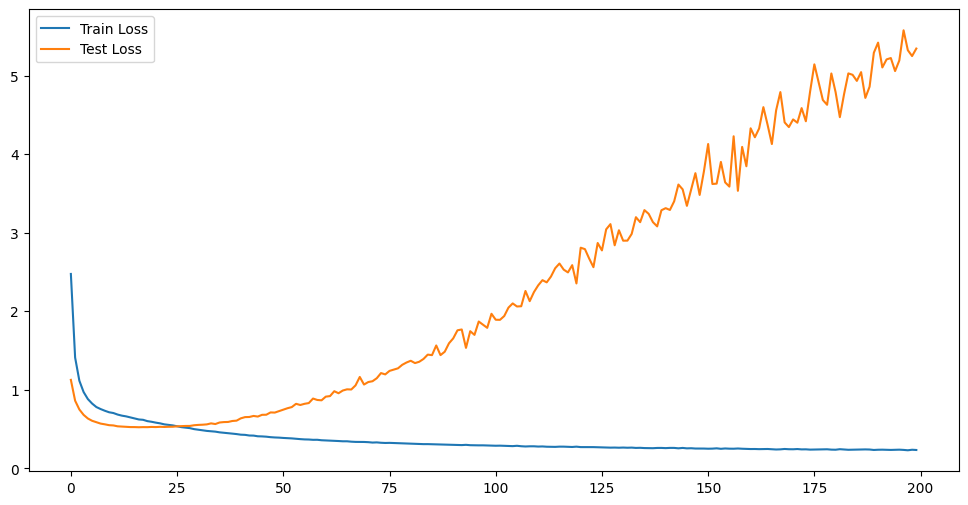

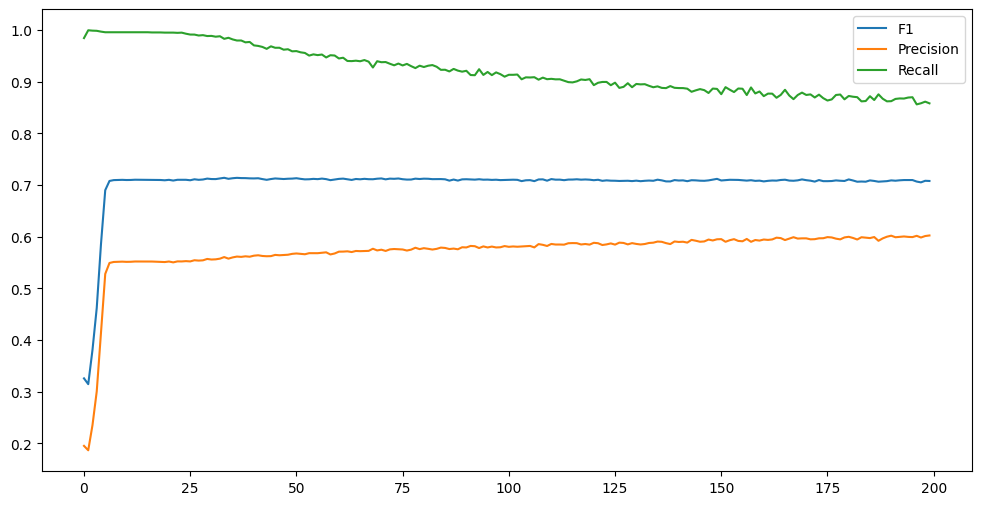

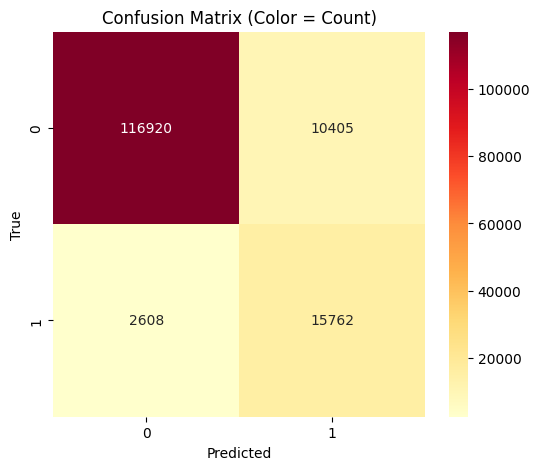

In [13]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# ----------------------------
# Config
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33
FEATURES = 20
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.6
CNN_FILTERS = 60
LSTM_HIDDEN = 5
USE_LSTM = True
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.50  # threshold used for converting probs -> preds

# ----------------------------
# Dataset
# ----------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','')\
                                         .replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','')\
                                      .replace("'",'').replace(" ",'').replace('[','').replace(']','')

        amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()
        labels_tensor = torch.tensor(labels).float()
        return sequence_tensor, labels_tensor

# ----------------------------
# Model
# ----------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)
        
        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            self.lstm_dropout = nn.Dropout(dropout)
            fc_in = lstm_hidden*2
        else:
            fc_in = cnn_filters
        
        self.fc = nn.Linear(fc_in,1)

    def forward(self,x):
        x = x.transpose(1,2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1,2)
        x = self.dropout(x)
        
        if self.use_lstm:
            x,_ = self.lstm(x)
            x = self.lstm_dropout(x)
        
        logits = self.fc(x).squeeze(-1)
        return logits

# ----------------------------
# PTM Focal Loss
# ----------------------------
class PTMFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=20.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=torch.tensor([self.pos_weight], device=logits.device),
            reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = (1 - pt) ** self.gamma
        alpha_factor = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        loss = focal * alpha_factor * bce
        num_pos = targets.sum() + 1e-6
        return loss.sum() / num_pos

# ----------------------------
# Instantiate model
# ----------------------------
model = PhosphoModel().to(DEVICE)
criterion = PTMFocalLoss(alpha=0.7, gamma=2.0, pos_weight=20.0)
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# Load datasets
# ----------------------------
train_dataset = ProteinDataset("code_test_data.csv")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ProteinDataset("code_predict.csv")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Training loop
# ----------------------------
best_f1 = 0.0
history = {"train_loss":[],"test_loss":[],"test_f1":[],"precision":[],"recall":[],"pos_acc":[]}

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    train_steps = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_steps += 1

    train_loss /= train_steps
    history["train_loss"].append(train_loss)

    # ---- Evaluation ----
    model.eval()
    test_loss = 0.0
    test_steps = 0
    total_tp = total_fp = total_fn = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            loss = criterion(logits, labels).item()
            test_loss += loss
            test_steps += 1

            # only focus on positives, ignore TN
            tp = ((torch.sigmoid(logits) > THRESH).int() & labels.int()).sum().item()
            fp = ((torch.sigmoid(logits) > THRESH).int() & (labels.int()==0)).sum().item()
            fn = ((torch.sigmoid(logits) <= THRESH).int() & labels.int()).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn

    test_loss /= test_steps
    history["test_loss"].append(test_loss)

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    history["test_f1"].append(f1)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["pos_acc"].append(recall)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} "
          f"| F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | TP: {total_tp} FP: {total_fp} FN: {total_fn}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model with F1: {best_f1:.4f}")

# ----------------------------
# Plot metrics
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history["test_f1"], label="F1")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.legend()
plt.show()

# ----------------------------
# Colorful confusion matrix
# ----------------------------
all_targets = []
all_preds = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        logits = model(inputs)
        preds = (torch.sigmoid(logits) > THRESH).int()
        all_targets.append(labels.cpu())
        all_preds.append(preds.cpu())

# Flatten to 1D
all_targets = torch.cat(all_targets).view(-1).numpy()
all_preds = torch.cat(all_preds).view(-1).numpy()

# Compute confusion matrix focusing on positives (TN included for completeness)
TP = ((all_preds == 1) & (all_targets == 1)).sum()
FP = ((all_preds == 1) & (all_targets == 0)).sum()
FN = ((all_preds == 0) & (all_targets == 1)).sum()
TN = ((all_preds == 0) & (all_targets == 0)).sum()

conf_matrix = np.array([[TN, FP],
                        [FN, TP]])

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlOrRd", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Color = Count)")
plt.show()


In [ ]:
#best is .6,64,2
#.715 .6,.80,3


#.715
DROPOUT = 0.65
CNN_FILTERS = 96
LSTM_HIDDEN = 3

# turning off LSTM

In [4]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# ----------------------------
# Config
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 33
FEATURES = 20
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 200
DROPOUT = 0.65
CNN_FILTERS = 96
LSTM_HIDDEN = 3
USE_LSTM = False
CHECKPOINT_PATH = "best_phospho_model.pth"
THRESH = 0.50  # threshold used for converting probs -> preds

# ----------------------------
# Dataset
# ----------------------------
class ProteinDataset(Dataset):
    def __init__(self, csv_file, sequence_length=SEQ_LEN):
        self.data = pd.read_csv(csv_file)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx, 1].replace('\r','').replace('\n','').replace('"','')\
                                         .replace("'",'').replace(" ",'').replace('[','').replace(']','')
        labels = self.data.iloc[idx, 2].replace('\r','').replace('\n','').replace('"','')\
                                      .replace("'",'').replace(" ",'').replace('[','').replace(']','')

        amino_acid_dict = {
            'A':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'R':[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'N':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'D':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'C':[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'E':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'Q':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
            'G':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
            'H':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
            'I':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
            'L':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
            'K':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
            'M':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
            'F':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
            'P':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0],
            'S':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],
            'T':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
            'W':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
            'Y':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
            'V':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]
        }

        sequence_indices = [amino_acid_dict[aa] for aa in sequence]
        labels = [int(label) for label in labels.split(",")]

        sequence_tensor = torch.tensor(sequence_indices).float()
        labels_tensor = torch.tensor(labels).float()
        return sequence_tensor, labels_tensor

# ----------------------------
# Model
# ----------------------------
class PhosphoModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, input_dim=FEATURES, cnn_filters=CNN_FILTERS,
                 lstm_hidden=LSTM_HIDDEN, use_lstm=USE_LSTM, dropout=DROPOUT):
        super().__init__()
        self.use_lstm = use_lstm
        self.conv1 = nn.Conv1d(input_dim, cnn_filters, 7, padding=3)
        self.bn1 = nn.BatchNorm1d(cnn_filters)
        self.conv2 = nn.Conv1d(cnn_filters, cnn_filters, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(cnn_filters)
        self.dropout = nn.Dropout(dropout)
        
        if use_lstm:
            self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                                bidirectional=True, batch_first=True)
            self.lstm_dropout = nn.Dropout(dropout)
            fc_in = lstm_hidden*2
        else:
            fc_in = cnn_filters
        
        self.fc = nn.Linear(fc_in,1)

    def forward(self,x):
        x = x.transpose(1,2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.transpose(1,2)
        x = self.dropout(x)
        
        if self.use_lstm:
            x,_ = self.lstm(x)
            x = self.lstm_dropout(x)
        else:
            x = x
        logits = self.fc(x).squeeze(-1)
        return logits

# ----------------------------
# PTM Focal Loss
# ----------------------------
class PTMFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=20.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=torch.tensor([self.pos_weight], device=logits.device),
            reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = (1 - pt) ** self.gamma
        alpha_factor = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        loss = focal * alpha_factor * bce
        num_pos = targets.sum() + 1e-6
        return loss.sum() / num_pos

# ----------------------------
# Instantiate model
# ----------------------------
model = PhosphoModel().to(DEVICE)
criterion = PTMFocalLoss(alpha=0.7, gamma=2.0, pos_weight=20.0)
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# Load datasets
# ----------------------------
train_dataset = ProteinDataset("code_test_data.csv")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ProteinDataset("code_predict.csv")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------
# Training loop
# ----------------------------
best_f1 = 0.0
history = {"train_loss":[],"test_loss":[],"test_f1":[],"precision":[],"recall":[],"pos_acc":[]}

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    train_steps = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_steps += 1

    train_loss /= train_steps
    history["train_loss"].append(train_loss)

    # ---- Evaluation ----
    model.eval()
    test_loss = 0.0
    test_steps = 0
    total_tp = total_fp = total_fn = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            loss = criterion(logits, labels).item()
            test_loss += loss
            test_steps += 1

            # only focus on positives, ignore TN
            tp = ((torch.sigmoid(logits) > THRESH).int() & labels.int()).sum().item()
            fp = ((torch.sigmoid(logits) > THRESH).int() & (labels.int()==0)).sum().item()
            fn = ((torch.sigmoid(logits) <= THRESH).int() & labels.int()).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn

    test_loss /= test_steps
    history["test_loss"].append(test_loss)

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    history["test_f1"].append(f1)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["pos_acc"].append(recall)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} "
          f"| F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | TP: {total_tp} FP: {total_fp} FN: {total_fn}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Saved best model with F1: {best_f1:.4f}")

# ----------------------------
# Plot metrics
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history["test_f1"], label="F1")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.legend()
plt.show()

# ----------------------------
# Colorful confusion matrix
# ----------------------------
all_targets = []
all_preds = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        logits = model(inputs)
        preds = (torch.sigmoid(logits) > THRESH).int()
        all_targets.append(labels.cpu())
        all_preds.append(preds.cpu())

# Flatten to 1D
all_targets = torch.cat(all_targets).view(-1).numpy()
all_preds = torch.cat(all_preds).view(-1).numpy()

# Compute confusion matrix focusing on positives (TN included for completeness)
TP = ((all_preds == 1) & (all_targets == 1)).sum()
FP = ((all_preds == 1) & (all_targets == 0)).sum()
FN = ((all_preds == 0) & (all_targets == 1)).sum()
TN = ((all_preds == 0) & (all_targets == 0)).sum()

conf_matrix = np.array([[TN, FP],
                        [FN, TP]])

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlOrRd", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Color = Count)")
plt.show()


Epoch 1/200 | Train Loss: 0.980862 | Test Loss: 0.597952 | F1: 0.6287 | Precision: 0.4593 | Recall: 0.9958 | TP: 18292 FP: 21532 FN: 78
✅ Saved best model with F1: 0.6287
Epoch 2/200 | Train Loss: 0.615886 | Test Loss: 0.518264 | F1: 0.6976 | Precision: 0.5369 | Recall: 0.9956 | TP: 18289 FP: 15772 FN: 81
✅ Saved best model with F1: 0.6976
Epoch 3/200 | Train Loss: 0.531139 | Test Loss: 0.493680 | F1: 0.7071 | Precision: 0.5482 | Recall: 0.9956 | TP: 18289 FP: 15073 FN: 81
✅ Saved best model with F1: 0.7071
Epoch 4/200 | Train Loss: 0.485348 | Test Loss: 0.488305 | F1: 0.7088 | Precision: 0.5503 | Recall: 0.9956 | TP: 18289 FP: 14945 FN: 81
✅ Saved best model with F1: 0.7088
Epoch 5/200 | Train Loss: 0.454834 | Test Loss: 0.491830 | F1: 0.7091 | Precision: 0.5506 | Recall: 0.9956 | TP: 18289 FP: 14928 FN: 81
✅ Saved best model with F1: 0.7091
Epoch 6/200 | Train Loss: 0.436599 | Test Loss: 0.494619 | F1: 0.7092 | Precision: 0.5507 | Recall: 0.9956 | TP: 18289 FP: 14919 FN: 81
✅ Saved b

KeyboardInterrupt: 